# 1) Data

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [27]:
os.getcwd()

'C:\\Users\\ferna\\OneDrive\\Downloads\\GitHub\\ml_factorinv'

In [28]:
os.chdir('C:\\Users\\ferna\\OneDrive\\Downloads\\GitHub\\ml_factorinv')

In [29]:
data_raw = pd.read_csv('data/data_ml.csv', index_col=0) #data_raw

In [30]:
idx_date = (data_raw['date'] > '1999-12-31') & (data_raw['date'] < '2019-01-01')
data_ml = data_raw.loc[idx_date,:].copy() # obs in 2000-2018.
print(data_ml.shape[0], data_ml.shape[1]) # 268336 rows 99 columns.
print(data_ml.columns) # 1 col id, 1 col date, 93 cols of features, 4 cols of labels.
data_ml.iloc[0:5, 0:5] # Panel data in long format.

268336 99
Index(['stock_id', 'date', 'Advt_12M_Usd', 'Advt_3M_Usd', 'Advt_6M_Usd',
       'Asset_Turnover', 'Bb_Yld', 'Bv', 'Capex_Ps_Cf', 'Capex_Sales',
       'Cash_Div_Cf', 'Cash_Per_Share', 'Cf_Sales', 'Debtequity', 'Div_Yld',
       'Dps', 'Ebit_Bv', 'Ebit_Noa', 'Ebit_Oa', 'Ebit_Ta', 'Ebitda_Margin',
       'Eps', 'Eps_Basic', 'Eps_Basic_Gr', 'Eps_Contin_Oper', 'Eps_Dil', 'Ev',
       'Ev_Ebitda', 'Fa_Ci', 'Fcf', 'Fcf_Bv', 'Fcf_Ce', 'Fcf_Margin',
       'Fcf_Noa', 'Fcf_Oa', 'Fcf_Ta', 'Fcf_Tbv', 'Fcf_Toa', 'Fcf_Yld',
       'Free_Ps_Cf', 'Int_Rev', 'Interest_Expense', 'Mkt_Cap_12M_Usd',
       'Mkt_Cap_3M_Usd', 'Mkt_Cap_6M_Usd', 'Mom_11M_Usd', 'Mom_5M_Usd',
       'Mom_Sharp_11M_Usd', 'Mom_Sharp_5M_Usd', 'Nd_Ebitda', 'Net_Debt',
       'Net_Debt_Cf', 'Net_Margin', 'Netdebtyield', 'Ni', 'Ni_Avail_Margin',
       'Ni_Oa', 'Ni_Toa', 'Noa', 'Oa', 'Ocf', 'Ocf_Bv', 'Ocf_Ce', 'Ocf_Margin',
       'Ocf_Noa', 'Ocf_Oa', 'Ocf_Ta', 'Ocf_Tbv', 'Ocf_Toa', 'Op_Margin',
       'Op_Prt_Margin', 'Op

,stock_id,date,Advt_12M_Usd,Advt_3M_Usd,Advt_6M_Usd
1,13,2006-12-31,0.25,0.33,0.27
2,13,2007-01-31,0.25,0.32,0.28
3,13,2007-02-28,0.26,0.30,0.30
4,17,2015-03-31,0.73,0.64,0.70
5,17,2015-04-30,0.72,0.62,0.66


In [31]:
# data_ml.info() # All float64 except for stock_id (int64) and date (object)
data_ml['date'] = pd.to_datetime(data_ml['date'], format = '%Y-%m-%d')

Number of assets in each time

Text(0.5, 1.0, '# of assets available over time')

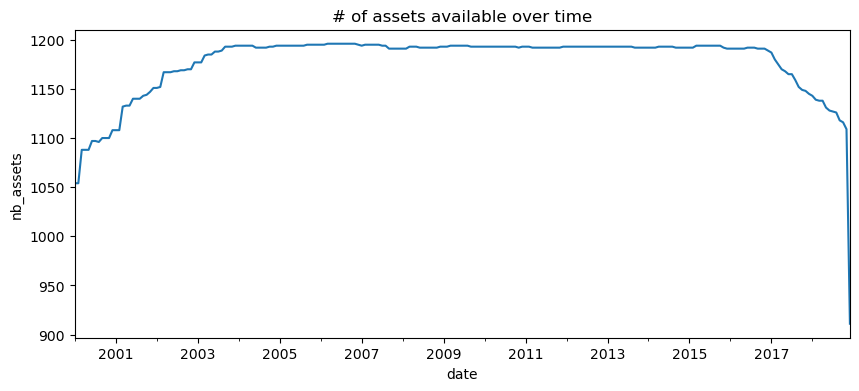

In [32]:
data_ml.groupby('date')['stock_id'].nunique().plot(figsize=(10,4))
#data_ml.groupby('date').size().plot(figsize=(8,4))
plt.ylabel('nb_assets')
plt.title('# of assets available over time')

##### Predictors: 
* all and short list
* store feature's column names
* predictors are uniformized (~U(0,1))

In [33]:
features=list(data_ml.iloc[:,3:95].columns)  
features_short =["Div_Yld", "Eps", "Mkt_Cap_12M_Usd", "Mom_11M_Usd", "Ocf", "Pb", "Vol1Y_Usd"]

##### Labels:  
* R1M_Usd, R3M_Usd, R6M_Usd and R12M_Usd, for regression. 
* R1M_Usd_C and R12M_Usd_C for classification. First create column for median returns on each data, then create categorical label.

In [34]:
df_median = data_ml.loc[:,['date','R1M_Usd','R12M_Usd']].groupby('date').median()
df_median.columns = ['R1M_Usd_median','R12M_Usd_median']
df_median.head(2) # 228 rows

,R1M_Usd_median,R12M_Usd_median
date,,
2000-01-31,-0.032,0.144
2000-02-29,0.060,0.190


In [35]:
df = pd.merge(data_ml,df_median, how = 'left', on = 'date') # check: same number of rows.
df.iloc[:,[0,1,2,3,4,-2,-1]]

,stock_id,date,Advt_12M_Usd,Advt_3M_Usd,Advt_6M_Usd,R1M_Usd_median,R12M_Usd_median
0,13,2006-12-31,0.25,0.33,0.27,0.019,-0.0560
1,13,2007-01-31,0.25,0.32,0.28,0.006,-0.0965
2,13,2007-02-28,0.26,0.30,0.30,0.006,-0.1350
3,17,2015-03-31,0.73,0.64,0.70,-0.025,-0.0320
4,17,2015-04-30,0.72,0.62,0.66,0.011,-0.0035
...,...,...,...,...,...,...,...
268331,1205,2004-05-31,0.97,0.97,0.98,0.041,0.0980
268332,1205,2004-07-31,0.97,0.96,0.98,0.007,0.1900
268333,1205,2004-08-31,0.97,0.96,0.97,0.039,0.1550
268334,1205,2004-09-30,0.97,0.96,0.97,0.020,0.1155


In [36]:
data_ml['R1M_Usd_C'] = np.where(df['R1M_Usd']>df['R1M_Usd_median'],1,0)
data_ml['R12M_Usd_C'] = np.where(df['R12M_Usd']>df['R12M_Usd_median'],1,0)

Training and testing

In [37]:
sep_date  = '2014-01-15'
idx_train = data_ml['date'].index[data_ml['date'] < sep_date]
idx_test  = data_ml['date'].index[data_ml['date'] >= sep_date]

Some other identifiers

In [38]:
stock_ids  = data_ml['stock_id'].unique() # list with ids of stocks.
stock_days = data_ml[['date','stock_id']].groupby('stock_id').count().reset_index() # number of dates per stock_id.
stock_ids_short = stock_days[stock_days.loc[:,'date'] == stock_days.loc[:,'date'].max()].loc[:,'stock_id'].to_list() # stocks present in all days.
is_stock_ids_short = data_ml['stock_id'].isin(stock_ids_short)

In [39]:
# BIASED
returns = data_ml[is_stock_ids_short].pivot(index = 'date', columns = 'stock_id', values = 'R1M_Usd')

In [40]:
stock_ids

array([ 13,  17,  29, ..., 331, 393, 950])

In [41]:
stock_days.head(5)

,stock_id,date
0,1,228
1,2,225
2,3,228
3,4,228
4,5,227


In [42]:
stock_ids_short[0:5]

[1, 3, 4, 7, 9]

In [43]:
is_stock_ids_short

1         False
2         False
3         False
4          True
5          True
          ...  
283376    False
283377    False
283378    False
283379    False
283380     True
Name: stock_id, Length: 268336, dtype: bool

In [44]:
#from data.data_load import * # script to import all above tretaments for data